# ViT vs CNN — ICLR'22 SAM Alignment (Chest X‑ray Pneumonia)

This notebook is a **clean, self‑contained** version of your experiments that:
- keeps your **recall‑first** evaluation (screening focus),
- trains **Custom ViT (scratch)** and **ViT‑B/16 (Google .npz)**,
- trains **Custom CNN (scratch)** and **ResNet‑18 (pretrained)**,
- optionally enables **SAM** (Sharpness‑Aware Minimization) for any model,
- follows the **Inception‑style preprocessing** and **optimizer/loss settings** recommended in Chen et al., *When Vision Transformers Outperform ResNets without Pre‑training or Strong Data Augmentations* (ICLR 2022).

> ⚠️ **Test set is untouched**. We create a **stratified validation split** from the provided `train/` folder and only use `test/` for the final report.

---



### What this notebook aligns with (paper → code)

- **Preprocessing**: Only *Inception‑style* transforms (RandomResizedCrop(224) + HorizontalFlip 0.5). No mixup/CutMix/RandAugment by default.

- **Optimizers**:
  - ViT: AdamW with weight decay `0.3` (paper Table 12), optional **SAM** with recommended `rho` (ViT‑B/16≈0.2; smaller ViT uses 0.05–0.1).

  - CNN/ResNet: SGD (momentum 0.9) or AdamW; optional **SAM** (rho 0.02–0.05).

- **Regularization**: Dropout 0.1 on ViT head; **stochastic depth** (DropPath) is available but **off** by default to match the paper’s baseline.

- **Metrics & thresholding**: Accuracy, Precision, Recall, F1, AUROC **and** a **recall‑first** calibrated threshold chosen on the **validation** set.



In [2]:

# --- Environment & Paths ---
from dataclasses import dataclass
from pathlib import Path
import os, math, time, random, copy, itertools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision as tv
from torchvision import transforms
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             confusion_matrix)
import matplotlib.pyplot as plt
# Device (MPS on macOS if available)
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)

# Paths (run from notebooks/)
REPO_ROOT   = Path.cwd().parent
DATASET_DIR = REPO_ROOT / "Data" / "chest_xray"
WEIGHTS_DIR = Path.cwd() / "weights"
WEIGHTS_DIR.mkdir(exist_ok=True, parents=True)

print("Dataset dir:", DATASET_DIR.resolve())
print("Weights dir:", WEIGHTS_DIR.resolve())

# Reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)


Device: mps
Dataset dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/Data/chest_xray
Weights dir: /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning/DeepLearning_2025/FinalProject_Deep/Deep-Learning-Project/notebooks/weights


In [ ]:

@dataclass
class Cfg:
    image_size: int = 224
    in_channels: int = 3
    batch_size: int = 32
    num_workers: int = 0

    use_stratified_val: bool = True
    stratified_val_size: float = 0.2  # from train/ -> val

    # ViT (scratch)
    scratch_epochs: int = 15
    scratch_lr: float = 3e-4
    scratch_wd: float = 0.05
    vit_embed_dim: int = 256
    vit_depth: int = 6
    vit_heads: int = 8
    vit_mlp_ratio: float = 4.0
    vit_drop: float = 0.1
    drop_path_rate: float = 0.0  # stochastic depth OFF to match paper

    # Pretrained ViT‑B/16
    pretrained_epochs: int = 10
    pretrained_lr: float = 1e-4
    pretrained_wd: float = 0.3  # paper uses 0.3 for ViT

    # CNN baselines
    cnn_epochs: int = 15
    cnn_lr: float = 1e-3
    cnn_wd: float = 1e-4

    # SAM
    use_sam: bool = True
    sam_rho_vit_small: float = 0.1
    sam_rho_vit_b16: float = 0.2
    sam_rho_cnn: float = 0.05

    # Early stopping
    patience: int = 5
    monitor: str = 'va_auroc'

    # Loss
    use_class_weights: bool = True
    label_smoothing: float = 0.05

    # Screening
    target_recall: float = 0.95

cfg = Cfg()
print(cfg)


Cfg(image_size=224, in_channels=3, batch_size=32, num_workers=0, use_stratified_val=True, stratified_val_size=0.2, scratch_epochs=15, scratch_lr=0.0003, scratch_wd=0.05, vit_embed_dim=256, vit_depth=6, vit_heads=8, vit_mlp_ratio=4.0, vit_drop=0.1, drop_path_rate=0.0, pretrained_epochs=10, pretrained_lr=0.0001, pretrained_wd=0.3, cnn_epochs=15, cnn_lr=0.001, cnn_wd=0.0001, use_sam=True, sam_rho_vit_small=0.1, sam_rho_vit_b16=0.2, sam_rho_cnn=0.05, patience=5, monitor='va_auroc', use_class_weights=True, label_smoothing=0.05, target_recall=0.95)


In [21]:
# --- Datasets & Inception-style preprocessing ---
# Train: RandomResizedCrop(224) + HorizontalFlip(0.5)
# Val/Test: Resize(256) + CenterCrop(224)

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torchvision as tv  # safe to have; used by other cells

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(cfg.image_size, scale=(0.08, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Lambda(lambda img: img.convert("RGB")),        # <-- force 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(cfg.image_size),
    transforms.Lambda(lambda img: img.convert("RGB")),        # <-- force 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Load Kaggle directory
root = Path(DATASET_DIR)
ds_train_raw = datasets.ImageFolder(root / 'train', transform=train_tf)
ds_val_raw   = datasets.ImageFolder(root / 'val',   transform=eval_tf)
ds_test      = datasets.ImageFolder(root / 'test',  transform=eval_tf)
classes = ds_train_raw.classes
print('Classes:', classes)

# Stratified val from the provided train/ (merge official val into train pool)
# The Kaggle split already has a small val; we optionally re-split for more stability.
if cfg.use_stratified_val:
    # Merge official train + val, then stratify
    all_imgs = list(ds_train_raw.imgs) + list(ds_val_raw.imgs)
    all_targets = [y for (_, y) in all_imgs]
    all_paths = [p for (p, _) in all_imgs]

    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=cfg.stratified_val_size, random_state=42)
    idx_train, idx_val = next(sss.split(np.zeros(len(all_targets)), all_targets))

    class _DS(Dataset):
        def __init__(self, paths, targets, transform):
            self.paths, self.targets, self.transform = paths, targets, transform
            self.samples = list(zip(paths, targets))  # for compatibility
            self.classes = classes
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        def __len__(self): 
            return len(self.paths)
        def __getitem__(self, i):
            p, y = self.paths[i], self.targets[i]
            # PIL open -> ensure RGB -> transform
            img = Image.open(p).convert("RGB")         # <-- force 3 channels
            img = self.transform(img)
            return img, y

    train_ds = _DS([all_paths[i] for i in idx_train], [all_targets[i] for i in idx_train], train_tf)
    val_ds   = _DS([all_paths[i] for i in idx_val],   [all_targets[i] for i in idx_val],   eval_tf)
else:
    train_ds, val_ds = ds_train_raw, ds_val_raw

# Class counts for info
if hasattr(train_ds, 'samples'):
    train_counts = np.bincount([y for _, y in train_ds.samples], minlength=len(classes))
else:
    train_counts = np.bincount(train_ds.targets, minlength=len(classes))

print('Lens:', len(train_ds), len(val_ds), len(ds_test))
print('Train counts:', train_counts)

# DataLoaders
pin = (DEVICE.type == "cuda")   # avoid MPS pin_memory warnings
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=pin)
test_loader  = DataLoader(ds_test,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=pin)

# Sanity check
xb, yb = next(iter(train_loader))
print("Train batch shape (expect [B, 3, 224, 224]):", xb.shape)


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079 3106]
Train batch shape (expect [B, 3, 224, 224]): torch.Size([32, 3, 224, 224])


In [23]:
# --- SAM optimizer wrapper (robust kwarg filtering) ---
import inspect
from torch.optim import Optimizer

class SAM(Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        sig = inspect.signature(base_optimizer.__init__)
        valid = {k: v for k, v in kwargs.items() if k in sig.parameters}
        defaults = dict(rho=rho, **valid)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **valid)
        self.rho = rho

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        gnorm = self._grad_norm()
        for group in self.param_groups:
            scale = self.rho / (gnorm + 1e-12)
            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                p.add_(p.grad * scale)
        if zero_grad: self.zero_grad(set_to_none=True)

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]
        self.base_optimizer.step()
        if zero_grad: self.zero_grad(set_to_none=True)

    def step(self, closure=None):
        if closure is None:
            raise RuntimeError("SAM.step() requires a closure")
        loss = closure()
        self.first_step(zero_grad=True)
        closure()
        self.second_step(zero_grad=True)
        return loss

    def zero_grad(self, set_to_none=True):
        self.base_optimizer.zero_grad(set_to_none=set_to_none)

    def _grad_norm(self):
        device = self.param_groups[0]["params"][0].device
        norms = []
        for g in self.param_groups:
            for p in g["params"]:
                if p.grad is None: continue
                norms.append(torch.norm(p.grad.detach(), p=2).to(device))
        return torch.norm(torch.stack(norms), p=2) if norms else torch.tensor(0.0, device=device)


In [25]:

# --- Metrics, threshold search (recall-first), and plots ---
def choose_threshold_by_min_recall(y_true, p1, min_recall=0.95):
    prec, rec, thr = precision_recall_curve(y_true, p1)
    thr = np.append(thr, 1.0)  # align lengths
    mask = rec >= min_recall
    if not np.any(mask):
        # fallback to best F1
        f1 = 2 * (prec*rec)/(prec+rec+1e-9)
        i = np.nanargmax(f1)
        return float(thr[i]), float(rec[i]), float(prec[i]), float(f1[i])
    # among feasible thresholds, pick the one with highest precision
    i = np.argmax(prec[mask])
    idx = np.arange(len(prec))[mask][i]
    f1 = 2 * (prec[idx]*rec[idx])/(prec[idx]+rec[idx]+1e-9)
    return float(thr[idx]), float(rec[idx]), float(prec[idx]), float(f1)

def summarize_at_threshold(y, p1, thr):
    yhat = (p1 >= thr).astype(int)
    return {
        'acc': accuracy_score(y, yhat),
        'precision': precision_score(y, yhat, zero_division=0),
        'recall': recall_score(y, yhat, zero_division=0),
        'f1': f1_score(y, yhat, zero_division=0),
        'auroc': roc_auc_score(y, p1),
        'thr': float(thr),
    }

def plot_curve(tr, va, title):
    plt.figure(figsize=(6,4)); plt.plot(tr, label='train'); plt.plot(va, label='val')
    plt.title(title); plt.xlabel('epoch'); plt.legend(); plt.show()

def plot_two_series(a, a_lbl, b, b_lbl, title):
    plt.figure(figsize=(6,4)); plt.plot(a, label=a_lbl); plt.plot(b, label=b_lbl)
    plt.title(title); plt.xlabel('epoch'); plt.legend(); plt.show()

def diag_plots(model_name, probs, y_true, thr, auroc=None):
    import numpy as np, matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, average_precision_score
    y_hat = (probs[:,1] >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat)

    # Confusion
    plt.figure(figsize=(4,4)); plt.imshow(cm, interpolation='nearest'); plt.title(f"{model_name} — Confusion (cal)")
    plt.colorbar(); ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

    # ROC
    fpr, tpr, _ = roc_curve(y_true, probs[:,1])
    from sklearn.metrics import roc_auc_score
    if auroc is None: auroc = roc_auc_score(y_true, probs[:,1])
    plt.figure(figsize=(5,4)); plt.plot(fpr, tpr, lw=2); plt.plot([0,1],[0,1],'--')
    plt.title(f"{model_name} — ROC (AUROC={auroc:.4f})"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.tight_layout(); plt.show()

    # PR
    prec, rec, _ = precision_recall_curve(y_true, probs[:,1])
    ap = average_precision_score(y_true, probs[:,1])
    plt.figure(figsize=(5,4)); plt.plot(rec, prec, lw=2)
    plt.title(f"{model_name} — PR (AP={ap:.4f})"); plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout(); plt.show()


In [26]:

# --- Minimal Custom CNN (scratch) ---
class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, num_classes))
    def forward(self, x):
        x = self.features(x); x = self.classifier(x); return x

def build_resnet18(pretrained=True, num_classes=2):
    m = tv.models.resnet18(weights=tv.models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

# --- ViT (scratch) ---
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.):
        super().__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        if self.drop_prob == 0. or not self.training: return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim-1)
        random_tensor = keep + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()
        return x.div(keep) * random_tensor

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features, act_layer=nn.GELU, drop=0.):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)
    def forward(self, x):
        x = self.fc1(x); x = self.act(x); x = self.drop(x); x = self.fc2(x); x = self.drop(x); return x

class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2,-1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1,2).reshape(B, N, C)
        x = self.proj(x); x = self.proj_drop(x); return x

class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=True, drop=0., attn_drop=0., drop_path=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.drop_path = DropPath(drop_path)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(dim, int(dim*mlp_ratio), drop=drop)
    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

class PatchEmbed(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, embed_dim=768):
        super().__init__()
        self.img_size = img_size; self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) * (img_size // patch_size)
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)  # B, C, H/ps, W/ps
        x = x.flatten(2).transpose(1,2)  # B, N, C
        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=2,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.,
                 qkv_bias=True, drop_rate=0.1, drop_path_rate=0.0):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches+1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads, mlp_ratio, qkv_bias, drop=drop_rate, attn_drop=0., drop_path=dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(nn.Dropout(drop_rate), nn.Linear(embed_dim, num_classes))

        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)  # B, N, C
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls, x), dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks: x = blk(x)
        x = self.norm(x)
        cls_out = x[:,0]
        return self.head(cls_out)


In [27]:

# --- Robust loader for Google ViT-B/16 .npz (handles both key variants) ---
@torch.no_grad()
def _get_any(w, keys):
    for k in keys:
        if k in w: return w[k]
    raise KeyError(f"None of keys found: {keys}")

@torch.no_grad()
def load_jax_vit_npz_into_pytorch(model, npz_path: str | Path):
    w = np.load(str(npz_path))
    D = model.head[-1].in_features  # embed dim
    def n2t(x): return torch.from_numpy(x).float()

    # Patch embed
    model.patch_embed.proj.weight.copy_(n2t(w['embedding/kernel']).permute(3,2,0,1))
    model.patch_embed.proj.bias.copy_(n2t(w['embedding/bias']))

    # CLS + posemb (with interpolation if grid mismatch)
    model.cls_token.copy_(n2t(w['cls']))
    posemb = w['Transformer/posembed_input/pos_embedding']
    if posemb.shape[1] != model.pos_embed.shape[1]:
        cls_pos = posemb[:, :1]
        grid_pos = posemb[:, 1:]
        gs_old = int(np.sqrt(grid_pos.shape[1]))
        grid_pos = grid_pos.reshape(1, gs_old, gs_old, D).transpose(0,3,1,2)
        H = W = int((model.patch_embed.num_patches) ** 0.5)
        grid_pos = F.interpolate(n2t(grid_pos), size=(H, W), mode='bicubic', align_corners=False)
        grid_pos = grid_pos.permute(0,2,3,1).reshape(1, H*W, D).numpy()
        posemb = np.concatenate([cls_pos, grid_pos], axis=1)
    model.pos_embed.copy_(n2t(posemb))

    def flatten_qkv(W, b):
        if W.ndim == 3: W = W.reshape(W.shape[0], -1)
        b = b.reshape(-1)
        return W, b
    def flatten_out(Wo):
        if Wo.ndim == 3: Wo = Wo.reshape(-1, Wo.shape[-1])
        return Wo.T

    for i, blk in enumerate(model.blocks):
        blk.norm1.weight.copy_(n2t(_get_any(w,[f'Transformer/encoderblock_{i}/LayerNorm_0/scale'])))
        blk.norm1.bias.copy_(n2t(_get_any(w,[f'Transformer/encoderblock_{i}/LayerNorm_0/bias'])))
        blk.norm2.weight.copy_(n2t(_get_any(w,[f'Transformer/encoderblock_{i}/LayerNorm_2/scale'])))
        blk.norm2.bias.copy_(n2t(_get_any(w,[f'Transformer/encoderblock_{i}/LayerNorm_2/bias'])))

        # q,k,v
        Wq = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/query/kernel'])
        bq = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/query/bias'])
        Wk = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/key/kernel'])
        bk = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/key/bias'])
        Wv = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/value/kernel'])
        bv = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/value/bias'])
        Wq, bq = flatten_qkv(Wq, bq); Wk, bk = flatten_qkv(Wk, bk); Wv, bv = flatten_qkv(Wv, bv)
        Wqkv = np.concatenate([Wq, Wk, Wv], axis=1).T; bqkv = np.concatenate([bq, bk, bv], axis=0)
        blk.attn.qkv.weight.copy_(n2t(Wqkv)); blk.attn.qkv.bias.copy_(n2t(bqkv))

        # out
        Wo = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/out/kernel'])
        bo = _get_any(w,[f'Transformer/encoderblock_{i}/MultiHeadDotProductAttention_1/out/bias'])
        blk.attn.proj.weight.copy_(n2t(flatten_out(Wo))); blk.attn.proj.bias.copy_(n2t(bo))

        # MLP — support both key schemes
        Wm0 = _get_any(w,[f'Transformer/encoderblock_{i}/Mlp/Dense_0/kernel', f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_0/kernel'])
        bm0 = _get_any(w,[f'Transformer/encoderblock_{i}/Mlp/Dense_0/bias',   f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_0/bias'])
        Wm1 = _get_any(w,[f'Transformer/encoderblock_{i}/Mlp/Dense_1/kernel', f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_1/kernel'])
        bm1 = _get_any(w,[f'Transformer/encoderblock_{i}/Mlp/Dense_1/bias',   f'Transformer/encoderblock_{i}/MlpBlock_3/Dense_1/bias'])
        blk.mlp.fc1.weight.copy_(n2t(Wm0).T); blk.mlp.fc1.bias.copy_(n2t(bm0))
        blk.mlp.fc2.weight.copy_(n2t(Wm1).T); blk.mlp.fc2.bias.copy_(n2t(bm1))

    model.norm.weight.copy_(n2t(w['Transformer/encoder_norm/scale']))
    model.norm.bias.copy_(n2t(w['Transformer/encoder_norm/bias']))
    return model


In [28]:
# --- Training / Evaluation with optional SAM and early stopping ---
import copy
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def make_criterion(class_weights=None, label_smoothing=0.0):
    w = class_weights.to(DEVICE) if class_weights is not None else None
    return nn.CrossEntropyLoss(weight=w, label_smoothing=label_smoothing)

def train_model(model, train_loader, val_loader, device, epochs, base_lr, weight_decay,
                class_weights=None, monitor='va_auroc', patience=5,
                use_sam=False, sam_rho=0.05, tag='model'):

    model = model.to(device)
    crit = make_criterion(class_weights, cfg.label_smoothing)

    # Choose base optimizer class by model type
    base_opt_cls = torch.optim.AdamW if isinstance(model, VisionTransformer) else torch.optim.SGD
    wd = 0.0 if weight_decay is None else float(weight_decay)

    if use_sam:
        if base_opt_cls is torch.optim.SGD:
            opt = SAM(model.parameters(), torch.optim.SGD,
                      rho=sam_rho, lr=base_lr, weight_decay=wd, momentum=0.9, nesterov=True)
        else:
            opt = SAM(model.parameters(), torch.optim.AdamW,
                      rho=sam_rho, lr=base_lr, weight_decay=wd)
    else:
        if base_opt_cls is torch.optim.SGD:
            opt = torch.optim.SGD(model.parameters(), lr=base_lr, weight_decay=wd,
                                  momentum=0.9, nesterov=True)
        else:
            opt = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=wd)

    best_state = None; best_metric = -1e9; no_improve = 0
    hist = {'tr_loss': [], 'va_loss': [], 'va_acc': [], 'va_f1': [], 'va_auroc': []}
    t0 = time.time()

    for ep in range(1, epochs + 1):
        model.train(); tr_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            if use_sam:
                out = model(xb); loss = crit(out, yb); loss.backward()
                opt.first_step(zero_grad=True)
                out = model(xb); crit(out, yb).backward()
                opt.second_step(zero_grad=True)
            else:
                out = model(xb); loss = crit(out, yb)
                opt.zero_grad(); loss.backward(); opt.step()

            tr_losses.append(loss.item())

        # Validation
        model.eval(); va_losses = []; probs = []; targs = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                va_losses.append(crit(logits, yb).item())
                p1 = F.softmax(logits, dim=1)[:, 1]
                probs.append(p1.cpu().numpy()); targs.append(yb.cpu().numpy())

        probs = np.concatenate(probs); targs = np.concatenate(targs)
        yhat = (probs >= 0.5).astype(int)
        va_acc = accuracy_score(targs, yhat)
        va_f1  = f1_score(targs, yhat, zero_division=0)
        try:
            va_auroc = roc_auc_score(targs, probs)
        except Exception:
            va_auroc = float('nan')

        hist['tr_loss'].append(float(np.mean(tr_losses)))
        hist['va_loss'].append(float(np.mean(va_losses)))
        hist['va_acc'].append(float(va_acc))
        hist['va_f1'].append(float(va_f1))
        hist['va_auroc'].append(float(va_auroc))

        metric = va_auroc if monitor == 'va_auroc' else va_f1
        if metric > best_metric:
            best_metric = metric; best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1

        print(f"[{tag}] epoch {ep:02d}/{epochs:02d}  tr_loss={np.mean(tr_losses):.4f}  "
              f"val_loss={np.mean(va_losses):.4f}  val_acc={va_acc:.4f}  val_f1={va_f1:.4f}  "
              f"val_auroc={va_auroc:.4f}  (no_improve={no_improve})")

        if no_improve >= patience:
            print(f"[{tag}] early stopping at epoch {ep}."); break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, hist, time.time() - t0


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval(); p_list = []; t_list = []; logits_all = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        logits_all.append(logits.detach().cpu().numpy())
        p1 = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        p_list.append(p1); t_list.append(yb.numpy())
    p1 = np.concatenate(p_list); y = np.concatenate(t_list)
    return {'targets': y, 'probs': np.stack([1 - p1, p1], 1),
            'logits': np.concatenate(logits_all), 'auroc': roc_auc_score(y, p1)}


In [29]:
xb, yb = next(iter(train_loader))
print("Expect [B, 3, 224, 224] for ViT:", xb.shape)

Expect [B, 3, 224, 224] for ViT: torch.Size([32, 3, 224, 224])


[vit_scratch] epoch 01/15  tr_loss=0.7150  val_loss=0.7242  val_acc=0.4269  val_f1=0.3737  val_auroc=0.7886  (no_improve=0)
[vit_scratch] epoch 02/15  tr_loss=0.6695  val_loss=0.6197  val_acc=0.5941  val_f1=0.6461  val_auroc=0.7456  (no_improve=1)
[vit_scratch] epoch 03/15  tr_loss=0.6585  val_loss=0.6123  val_acc=0.5712  val_f1=0.6133  val_auroc=0.8144  (no_improve=0)
[vit_scratch] epoch 04/15  tr_loss=0.6524  val_loss=0.5809  val_acc=0.6781  val_f1=0.7406  val_auroc=0.8395  (no_improve=0)
[vit_scratch] epoch 05/15  tr_loss=0.5999  val_loss=0.5792  val_acc=0.6418  val_f1=0.6973  val_auroc=0.8132  (no_improve=1)
[vit_scratch] epoch 06/15  tr_loss=0.5566  val_loss=0.4601  val_acc=0.7927  val_f1=0.8440  val_auroc=0.9078  (no_improve=0)
[vit_scratch] epoch 07/15  tr_loss=0.5380  val_loss=0.5027  val_acc=0.6972  val_f1=0.7470  val_auroc=0.9140  (no_improve=0)
[vit_scratch] epoch 08/15  tr_loss=0.5101  val_loss=0.4211  val_acc=0.8481  val_f1=0.8913  val_auroc=0.9227  (no_improve=0)
[vit_scr

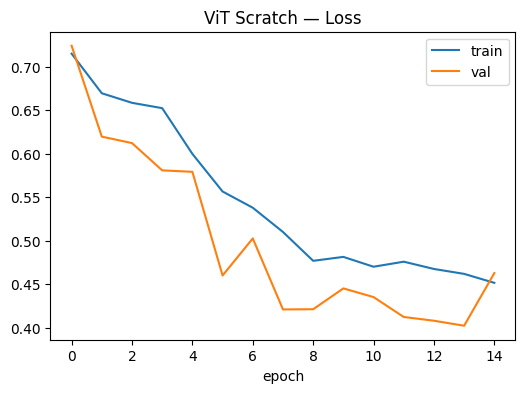

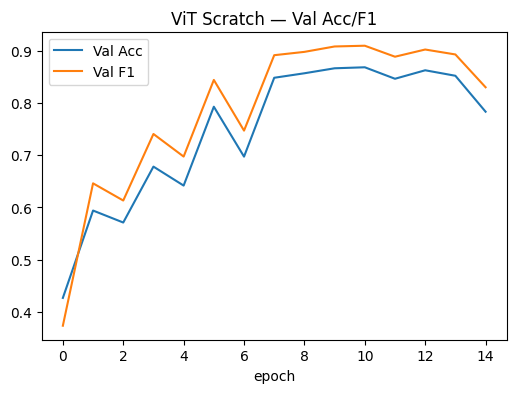

[Scratch] chosen thr on VAL: 0.077 (VAL recall=0.951, precision=0.868)
[ViT Scratch @0.5]  {'acc': 0.7628, 'precision': 0.898, 'recall': 0.7, 'f1': 0.7867, 'auroc': 0.8838, 'thr': 0.5}
[ViT Scratch @Rec]  {'acc': 0.7756, 'precision': 0.75, 'recall': 0.9615, 'f1': 0.8427, 'auroc': 0.8838, 'thr': 0.0775}


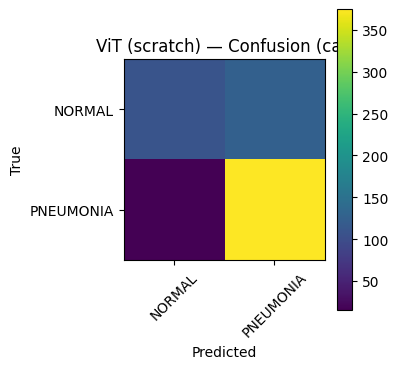

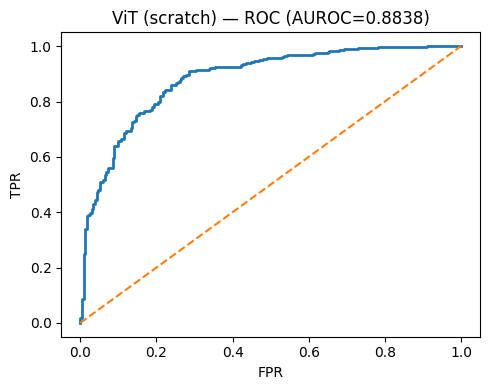

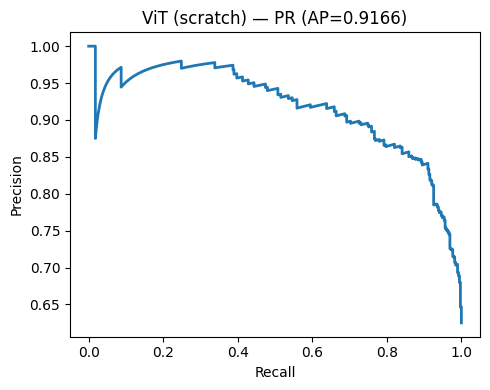

In [30]:
# ===== EXPERIMENT A: Custom ViT (scratch) + (optional) SAM =====
scratch_model = VisionTransformer(
    img_size=cfg.image_size, in_chans=cfg.in_channels, num_classes=2,
    embed_dim=cfg.vit_embed_dim, depth=cfg.vit_depth, num_heads=cfg.vit_heads,
    mlp_ratio=cfg.vit_mlp_ratio, drop_rate=cfg.vit_drop, drop_path_rate=cfg.drop_path_rate
).to(DEVICE)

# Class weights (to mitigate class imbalance)
cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    w = arr.sum() / (len(arr) * (arr + 1e-9))
    cw = torch.tensor(w, dtype=torch.float32)

scratch_model, hist_s, time_s = train_model(
    scratch_model, train_loader, val_loader, DEVICE,
    epochs=cfg.scratch_epochs, base_lr=cfg.scratch_lr, weight_decay=cfg.scratch_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='vit_scratch',
    use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_vit_small
)

plot_curve(hist_s['tr_loss'], hist_s['va_loss'], 'ViT Scratch — Loss')
plot_two_series(hist_s['va_acc'], 'Val Acc', hist_s['va_f1'], 'Val F1', 'ViT Scratch — Val Acc/F1')

# Recall-first validation -> test
val_out_s = evaluate(scratch_model, val_loader, DEVICE)
thr_s, r_s, p_s, f1_s = choose_threshold_by_min_recall(
    val_out_s['targets'], val_out_s['probs'][:,1], cfg.target_recall
)
print(f"[Scratch] chosen thr on VAL: {thr_s:.3f} (VAL recall={r_s:.3f}, precision={p_s:.3f})")

test_out_s = evaluate(scratch_model, test_loader, DEVICE)
y_test_s = test_out_s['targets']; p1_test_s = test_out_s['probs'][:,1]
summary_s_05   = summarize_at_threshold(y_test_s, p1_test_s, 0.5)
summary_s_reca = summarize_at_threshold(y_test_s, p1_test_s, thr_s)
print('[ViT Scratch @0.5] ', {k: round(v,4) for k,v in summary_s_05.items()})
print('[ViT Scratch @Rec] ', {k: round(v,4) for k,v in summary_s_reca.items()})
diag_plots('ViT (scratch)', test_out_s['probs'], y_test_s, thr_s, auroc=test_out_s.get('auroc'))

vit_scratch_results = {
    'summary@0.5': summary_s_05, 'summary@recall': summary_s_reca,
    'threshold': float(thr_s), 'time_sec': time_s,
    'params': sum(p.numel() for p in scratch_model.parameters())
}


Loaded Google ViT-B/16 .npz weights.
[vit_google_npz_pretrained_sam] epoch 01/10  tr_loss=0.5049  val_loss=0.3869  val_acc=0.8233  val_f1=0.8653  val_auroc=0.9785  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 02/10  tr_loss=0.3617  val_loss=0.3933  val_acc=0.8147  val_f1=0.8578  val_auroc=0.9872  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 03/10  tr_loss=0.3222  val_loss=0.3435  val_acc=0.8577  val_f1=0.8946  val_auroc=0.9910  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 04/10  tr_loss=0.2983  val_loss=0.3216  val_acc=0.8997  val_f1=0.9282  val_auroc=0.9915  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 05/10  tr_loss=0.2843  val_loss=0.2661  val_acc=0.9207  val_f1=0.9441  val_auroc=0.9917  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 06/10  tr_loss=0.2791  val_loss=0.2665  val_acc=0.9131  val_f1=0.9384  val_auroc=0.9937  (no_improve=0)
[vit_google_npz_pretrained_sam] epoch 07/10  tr_loss=0.2725  val_loss=0.2520  val_acc=0.9341  val_f1=0.9540  va

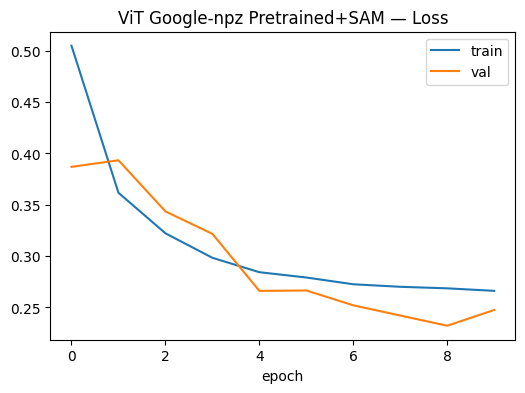

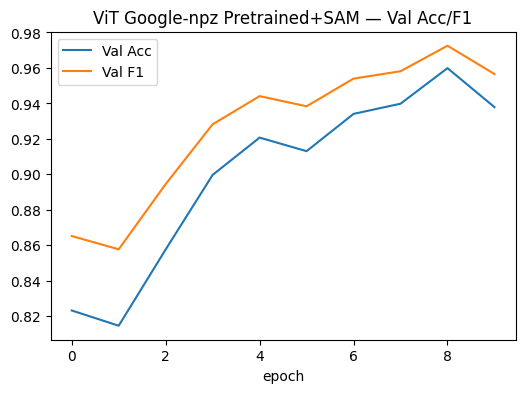

[ViT Pretrained+SAM] chosen thr on VAL: 0.288 (VAL recall=0.963, precision=0.991)
[ViT Pretrained+SAM @0.5] {'acc': 0.9311, 'precision': 0.9121, 'recall': 0.9846, 'f1': 0.947, 'auroc': 0.9859, 'thr': 0.5}
[ViT Pretrained+SAM @Rec] {'acc': 0.9279, 'precision': 0.9021, 'recall': 0.9923, 'f1': 0.9451, 'auroc': 0.9859, 'thr': 0.2882}


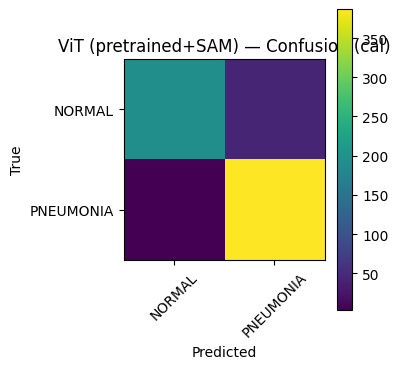

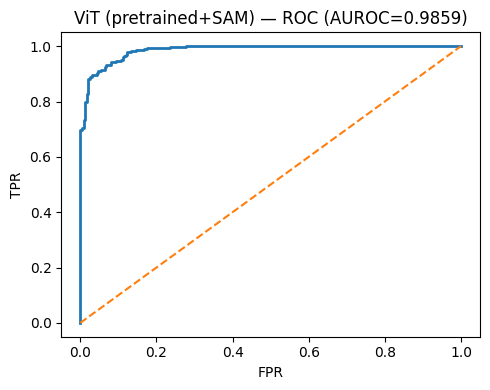

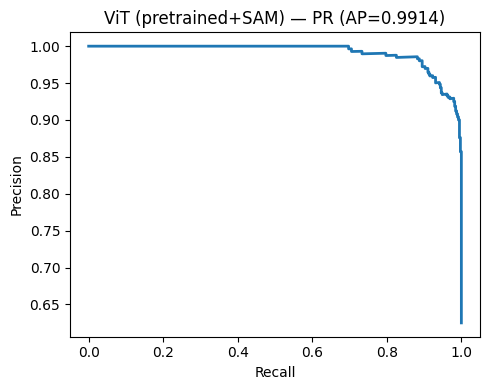

In [31]:

# ===== EXPERIMENT B: ViT-B/16 (Google .npz) + SAM =====
vit_b16 = VisionTransformer(
    img_size=cfg.image_size, patch_size=16, in_chans=3, num_classes=2,
    embed_dim=768, depth=12, num_heads=12, mlp_ratio=4.0, drop_rate=0.1, drop_path_rate=0.0
).to(DEVICE)

npz_path = WEIGHTS_DIR / 'ViT-B_16.npz'
if not npz_path.exists():
    print(f"WARNING: {npz_path} not found. You can still train ViT-B/16 from scratch (slower).")
else:
    vit_b16 = load_jax_vit_npz_into_pytorch(vit_b16, npz_path)
    print('Loaded Google ViT-B/16 .npz weights.')

cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    cw = torch.tensor(arr.sum() / (len(arr) * (arr + 1e-9)), dtype=torch.float32)

vit_b16, hist_pt, time_pt = train_model(
    vit_b16, train_loader, val_loader, DEVICE,
    epochs=cfg.pretrained_epochs, base_lr=cfg.pretrained_lr, weight_decay=cfg.pretrained_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='vit_google_npz_pretrained_sam',
    use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_vit_b16
)

plot_curve(hist_pt['tr_loss'], hist_pt['va_loss'], 'ViT Google-npz Pretrained+SAM — Loss')
plot_two_series(hist_pt['va_acc'], 'Val Acc', hist_pt['va_f1'], 'Val F1', 'ViT Google-npz Pretrained+SAM — Val Acc/F1')

val_eval_p = evaluate(vit_b16, val_loader, DEVICE)
thr_p, rec_p, prec_p, f1p = choose_threshold_by_min_recall(val_eval_p['targets'], val_eval_p['probs'][:,1], cfg.target_recall)
print(f"[ViT Pretrained+SAM] chosen thr on VAL: {thr_p:.3f} (VAL recall={rec_p:.3f}, precision={prec_p:.3f})")

test_eval_p = evaluate(vit_b16, test_loader, DEVICE)
p1_test = test_eval_p['probs'][:,1]; y_test = test_eval_p['targets']
summary_p_05   = summarize_at_threshold(y_test, p1_test, 0.5)
summary_p_reca = summarize_at_threshold(y_test, p1_test, thr_p)
print('[ViT Pretrained+SAM @0.5]', {k: round(v,4) for k,v in summary_p_05.items()})
print('[ViT Pretrained+SAM @Rec]', {k: round(v,4) for k,v in summary_p_reca.items()})
diag_plots('ViT (pretrained+SAM)', test_eval_p['probs'], y_test, thr_p, auroc=test_eval_p.get('auroc'))

vit_pretrained_results = {
    'summary@0.5': summary_p_05, 'summary@recall': summary_p_reca,
    'threshold': float(thr_p), 'time_sec': time_pt,
    'params': sum(p.numel() for p in vit_b16.parameters())
}


[cnn_scratch] epoch 01/15  tr_loss=0.7038  val_loss=0.7012  val_acc=0.2703  val_f1=0.0329  val_auroc=0.6775  (no_improve=0)
[cnn_scratch] epoch 02/15  tr_loss=0.7022  val_loss=0.6995  val_acc=0.2923  val_f1=0.0886  val_auroc=0.7227  (no_improve=0)
[cnn_scratch] epoch 03/15  tr_loss=0.7016  val_loss=0.6986  val_acc=0.3419  val_f1=0.2035  val_auroc=0.7398  (no_improve=0)
[cnn_scratch] epoch 04/15  tr_loss=0.7008  val_loss=0.6976  val_acc=0.4699  val_f1=0.4510  val_auroc=0.7511  (no_improve=0)
[cnn_scratch] epoch 05/15  tr_loss=0.7006  val_loss=0.6967  val_acc=0.5406  val_f1=0.5615  val_auroc=0.7603  (no_improve=0)
[cnn_scratch] epoch 06/15  tr_loss=0.6997  val_loss=0.6954  val_acc=0.5387  val_f1=0.5565  val_auroc=0.7701  (no_improve=0)
[cnn_scratch] epoch 07/15  tr_loss=0.6988  val_loss=0.6941  val_acc=0.6208  val_f1=0.6705  val_auroc=0.7700  (no_improve=1)
[cnn_scratch] epoch 08/15  tr_loss=0.6995  val_loss=0.6931  val_acc=0.6103  val_f1=0.6577  val_auroc=0.7767  (no_improve=0)
[cnn_scr

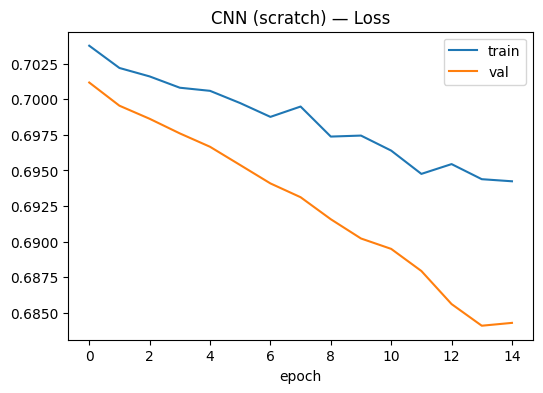

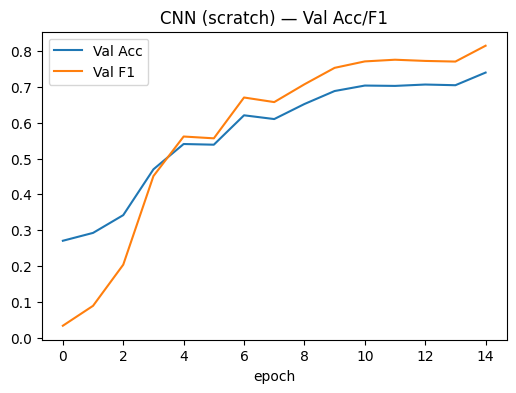

[CNN scratch @0.5] {'acc': 0.6747, 'precision': 0.7791, 'recall': 0.6692, 'f1': 0.72, 'auroc': 0.7076, 'thr': 0.5}
[CNN scratch @Rec] {'acc': 0.609, 'precision': 0.6225, 'recall': 0.9513, 'f1': 0.7525, 'auroc': 0.7076, 'thr': 0.456}


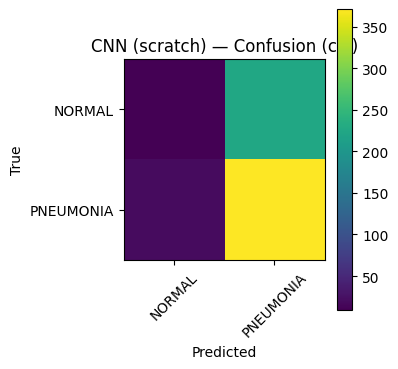

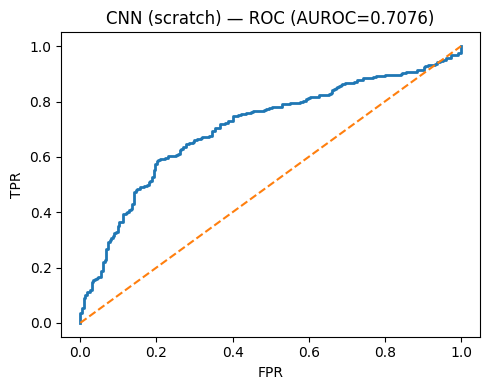

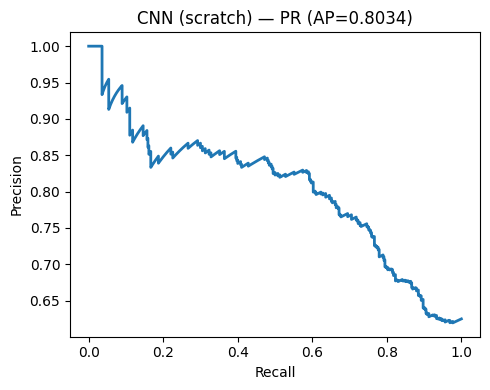

[resnet18_pretrained] epoch 01/15  tr_loss=0.4263  val_loss=0.3758  val_acc=0.8453  val_f1=0.8846  val_auroc=0.9810  (no_improve=0)
[resnet18_pretrained] epoch 02/15  tr_loss=0.3551  val_loss=0.3101  val_acc=0.8730  val_f1=0.9072  val_auroc=0.9903  (no_improve=0)
[resnet18_pretrained] epoch 03/15  tr_loss=0.3302  val_loss=0.2928  val_acc=0.8720  val_f1=0.9063  val_auroc=0.9922  (no_improve=0)
[resnet18_pretrained] epoch 04/15  tr_loss=0.3253  val_loss=0.2647  val_acc=0.9131  val_f1=0.9383  val_auroc=0.9932  (no_improve=0)
[resnet18_pretrained] epoch 05/15  tr_loss=0.3085  val_loss=0.2609  val_acc=0.9245  val_f1=0.9468  val_auroc=0.9933  (no_improve=0)
[resnet18_pretrained] epoch 06/15  tr_loss=0.3059  val_loss=0.2594  val_acc=0.9265  val_f1=0.9483  val_auroc=0.9935  (no_improve=0)
[resnet18_pretrained] epoch 07/15  tr_loss=0.3007  val_loss=0.2615  val_acc=0.9398  val_f1=0.9582  val_auroc=0.9926  (no_improve=1)
[resnet18_pretrained] epoch 08/15  tr_loss=0.2929  val_loss=0.2682  val_acc=

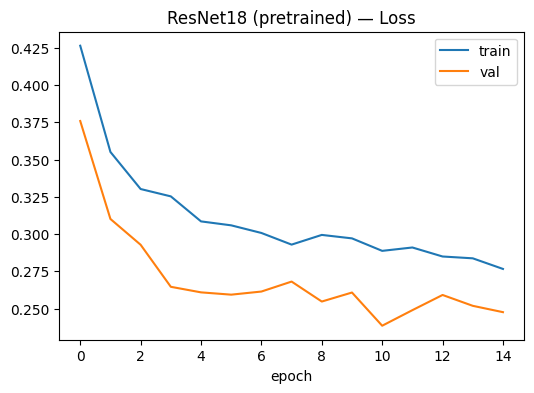

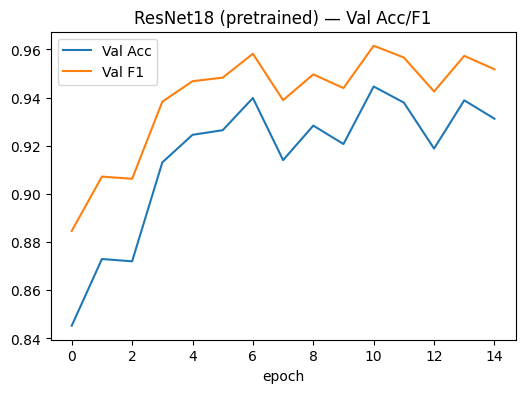

[ResNet18 @0.5] {'acc': 0.9407, 'precision': 0.9315, 'recall': 0.9769, 'f1': 0.9537, 'auroc': 0.9842, 'thr': 0.5}
[ResNet18 @Rec] {'acc': 0.9247, 'precision': 0.8979, 'recall': 0.9923, 'f1': 0.9428, 'auroc': 0.9842, 'thr': 0.2991}


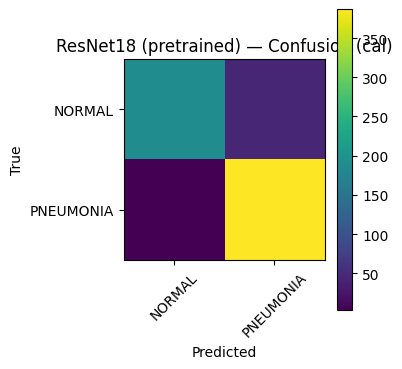

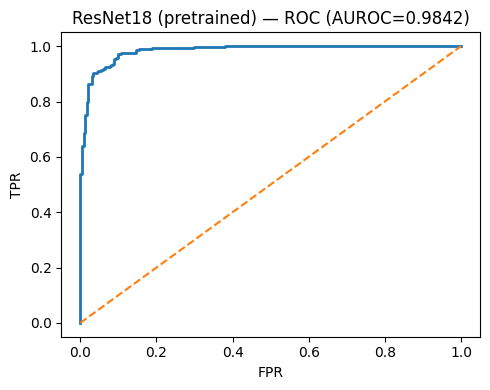

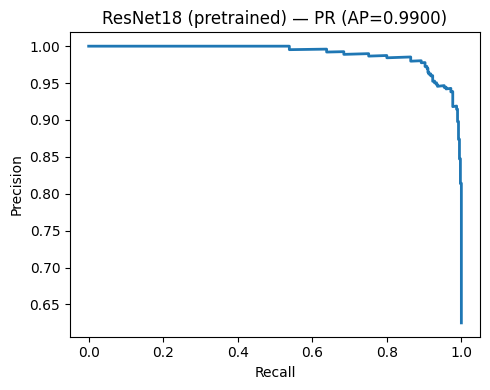

In [33]:

# ===== EXPERIMENT C: CNNs (scratch) and ResNet18 (pretrained) + optional SAM =====
# Small CNN (scratch)
cnn = SmallCNN(num_classes=2).to(DEVICE)
cw = None
if cfg.use_class_weights:
    arr = np.array(train_counts, dtype=float)
    cw = torch.tensor(arr.sum() / (len(arr) * (arr + 1e-9)), dtype=torch.float32)

cnn, hist_cnn, time_cnn = train_model(
    cnn, train_loader, val_loader, DEVICE,
    epochs=cfg.cnn_epochs, base_lr=cfg.cnn_lr, weight_decay=cfg.cnn_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='cnn_scratch',
    use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_cnn
)
plot_curve(hist_cnn['tr_loss'], hist_cnn['va_loss'], 'CNN (scratch) — Loss')
plot_two_series(hist_cnn['va_acc'], 'Val Acc', hist_cnn['va_f1'], 'Val F1', 'CNN (scratch) — Val Acc/F1')

val_eval_cnn = evaluate(cnn, val_loader, DEVICE)
thr_cnn, rec_cnn, prec_cnn, f1cnn = choose_threshold_by_min_recall(val_eval_cnn['targets'], val_eval_cnn['probs'][:,1], cfg.target_recall)
test_eval_cnn = evaluate(cnn, test_loader, DEVICE)
sum_cnn_05 = summarize_at_threshold(test_eval_cnn['targets'], test_eval_cnn['probs'][:,1], 0.5)
sum_cnn_rc = summarize_at_threshold(test_eval_cnn['targets'], test_eval_cnn['probs'][:,1], thr_cnn)
print('[CNN scratch @0.5]', {k: round(v,4) for k,v in sum_cnn_05.items()})
print('[CNN scratch @Rec]', {k: round(v,4) for k,v in sum_cnn_rc.items()})
diag_plots('CNN (scratch)', test_eval_cnn['probs'], test_eval_cnn['targets'], thr_cnn, auroc=test_eval_cnn.get('auroc'))

# ResNet18 (pretrained)
res18 = build_resnet18(pretrained=True, num_classes=2).to(DEVICE)
res18, hist_rn, time_rn = train_model(
    res18, train_loader, val_loader, DEVICE,
    epochs=cfg.cnn_epochs, base_lr=cfg.cnn_lr, weight_decay=cfg.cnn_wd,
    class_weights=cw, monitor=cfg.monitor, patience=cfg.patience, tag='resnet18_pretrained',
    use_sam=cfg.use_sam, sam_rho=cfg.sam_rho_cnn
)
plot_curve(hist_rn['tr_loss'], hist_rn['va_loss'], 'ResNet18 (pretrained) — Loss')
plot_two_series(hist_rn['va_acc'], 'Val Acc', hist_rn['va_f1'], 'Val F1', 'ResNet18 (pretrained) — Val Acc/F1')

val_eval_rn = evaluate(res18, val_loader, DEVICE)
thr_rn, rec_rn, prec_rn, f1rn = choose_threshold_by_min_recall(val_eval_rn['targets'], val_eval_rn['probs'][:,1], cfg.target_recall)
test_eval_rn = evaluate(res18, test_loader, DEVICE)
sum_rn_05 = summarize_at_threshold(test_eval_rn['targets'], test_eval_rn['probs'][:,1], 0.5)
sum_rn_rc = summarize_at_threshold(test_eval_rn['targets'], test_eval_rn['probs'][:,1], thr_rn)
print('[ResNet18 @0.5]', {k: round(v,4) for k,v in sum_rn_05.items()})
print('[ResNet18 @Rec]', {k: round(v,4) for k,v in sum_rn_rc.items()})
diag_plots('ResNet18 (pretrained)', test_eval_rn['probs'], test_eval_rn['targets'], thr_rn, auroc=test_eval_rn.get('auroc'))

cnn_results = {
    'cnn_scratch': {'summary@0.5': sum_cnn_05, 'summary@recall': sum_cnn_rc, 'threshold': float(thr_cnn),
                    'time_sec': time_cnn, 'params': sum(p.numel() for p in cnn.parameters())},
    'resnet18_pretrained': {'summary@0.5': sum_rn_05, 'summary@recall': sum_rn_rc, 'threshold': float(thr_rn),
                    'time_sec': time_rn, 'params': sum(p.numel() for p in res18.parameters())},
}


In [34]:

# ===== Part D: Unified comparison table =====
import pandas as pd
rows = []
def add_row(name, res):
    r = res['summary@recall']
    rows.append({
        'Model': name,
        'Params (M)': round(res['params']/1e6, 2),
        'Time (min)': round(res['time_sec']/60.0, 2),
        'Acc': round(r['acc'], 4),
        'Prec': round(r['precision'], 4),
        'Recall': round(r['recall'], 4),
        'F1': round(r['f1'], 4),
        'AUROC': round(r['auroc'], 4),
        'Thr': round(res['threshold'], 3)
    })

add_row('ViT (scratch' + ('+SAM' if cfg.use_sam else '') + ')', vit_scratch_results)
add_row('ViT-B/16 (pretrained' + ('+SAM' if cfg.use_sam else '') + ')', vit_pretrained_results)
add_row('CNN (scratch' + ('+SAM' if cfg.use_sam else '') + ')', cnn_results['cnn_scratch'])
add_row('ResNet18 (pretrained' + ('+SAM' if cfg.use_sam else '') + ')', cnn_results['resnet18_pretrained'])

df = pd.DataFrame(rows)
display(df)


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,ViT (scratch+SAM),4.99,27.36,0.7756,0.7500,0.9615,0.8427,0.8838,0.077
1,ViT-B/16 (pretrained+SAM),85.80,77.39,0.9279,0.9021,0.9923,0.9451,0.9859,0.288
2,CNN (scratch+SAM),0.09,16.39,0.6090,0.6225,0.9513,0.7525,0.7076,0.456
3,ResNet18 (pretrained+SAM),11.18,24.80,0.9247,0.8979,0.9923,0.9428,0.9842,0.299



### Notes on alignment with ICLR'22 paper

- **Why SAM?** The paper shows ViTs/Mixers converge to **sharp minima** and benefit **most** from smoothing the loss geometry; SAM explicitly optimizes for flatness and typically yields bigger gains for ViTs than for ResNets (see their Tables 1–2). This notebook enables **SAM for all models** and uses paper‑suggested **rho** (e.g., 0.2 for ViT‑B/16) by default.

- **Preprocessing parity**: We use only **Inception‑style** augmentation (random crop + flip). No mixup/CutMix/RandAugment here; you can toggle them later if needed.

- **Screening metric**: We keep your **recall‑first** thresholding so positive cases (PNEUMONIA) are prioritized, and we report both `@0.5` and `@Rec` summaries.

